### FUNDAMENTOS DA COMPUTAÇÃO QUÂNTICA - UA1/UA2 - CIRCUITO QUÂNTICO DE 2 QUBITS

In [ ]:
!pip install qiskit --quiet
!pip install qiskit-aer --quiet
!pip install pylatexenc --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 31.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Importação das bibliotecas necessárias
from qiskit import QuantumCircuit
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector
from matplotlib.gridspec import GridSpec

import qiskit.quantum_info as qi
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def get_bloch_vector(rho_reduced):
  SIGMA_X = np.array([[0, 1], [1, 0]], dtype=complex)
  SIGMA_Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
  SIGMA_Z = np.array([[1, 0], [0, -1]], dtype=complex)
  """Calcula o vetor de Bloch [x, y, z] a partir da Matriz Densidade reduzida (2x2)."""
  rho_data = rho_reduced.data # Extrai o array numpy 2x2 da Matriz Densidade

  # x = Tr(rho * sigma_x)
  x = np.trace(np.dot(rho_data, SIGMA_X)).real

  # y = Tr(rho * sigma_y)
  y = np.trace(np.dot(rho_data, SIGMA_Y)).real

  # z = Tr(rho * sigma_z)
  z = np.trace(np.dot(rho_data, SIGMA_Z)).real

  return np.array([x, y, z])

def draw_qc_sphere(qc):
  state = qi.Statevector(qc)
  bloch_fig = plot_bloch_multivector(state, title="")

  rho = qi.DensityMatrix(state)

  rho_q0 = qi.partial_trace(rho, qargs=[1])
  vector_q0 = get_bloch_vector(rho_q0)

  rho_q1 = qi.partial_trace(rho, qargs=[0])
  vector_q1 = get_bloch_vector(rho_q1)

  # Resultado: os vetores são arrays numpy [X, Y, Z]
  x0, y0, z0 = vector_q0
  x1, y1, z1 = vector_q1

  plt.close(bloch_fig)

  fig_main = plt.figure(figsize=(13, 5))
  gs = GridSpec(1, 4, figure=fig_main)

  latex_string = state.draw('latex')._repr_latex_()
  latex_string = latex_string.replace('$$', '').replace('\\n', ' ')
  latex_string = latex_string.replace('\\begin{pmatrix}', '\\begin{array}')
  latex_string = latex_string.replace('\\end{pmatrix}', '\\end{array}')
  latex_state = r'$|\psi\rangle = ' + latex_string.strip() + r'$'

  axs3 = fig_main.add_subplot(gs[0, 0])
  axs3.axis('off')

    # Adiciona o texto LaTeX
  fig_main.text(0.1, 0.5, latex_state,
                  fontsize=16,
                  ha='center',
                  va='center')

  axs0 = fig_main.add_subplot(gs[0, 1])
  qc.draw('mpl', ax=axs0, scale=1.0)
  axs0.set_title("Circuito Quântico", fontsize=14)

  axs1 = fig_main.add_subplot(gs[0, 2], projection='3d')
  plot_bloch_vector([x0, y0, z0], ax=axs1) # Plotamos o dado extraído
  axs1.set_title("qubit 0", fontsize=12, y=1.08)

  axs2 = fig_main.add_subplot(gs[0, 3], projection='3d')
  plot_bloch_vector([x1, y1, z1], ax=axs2) # Plotamos o dado extraído
  axs2.set_title("qubit 1", fontsize=12, y=1.08)

  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

### Criando circuito de 2 qubits

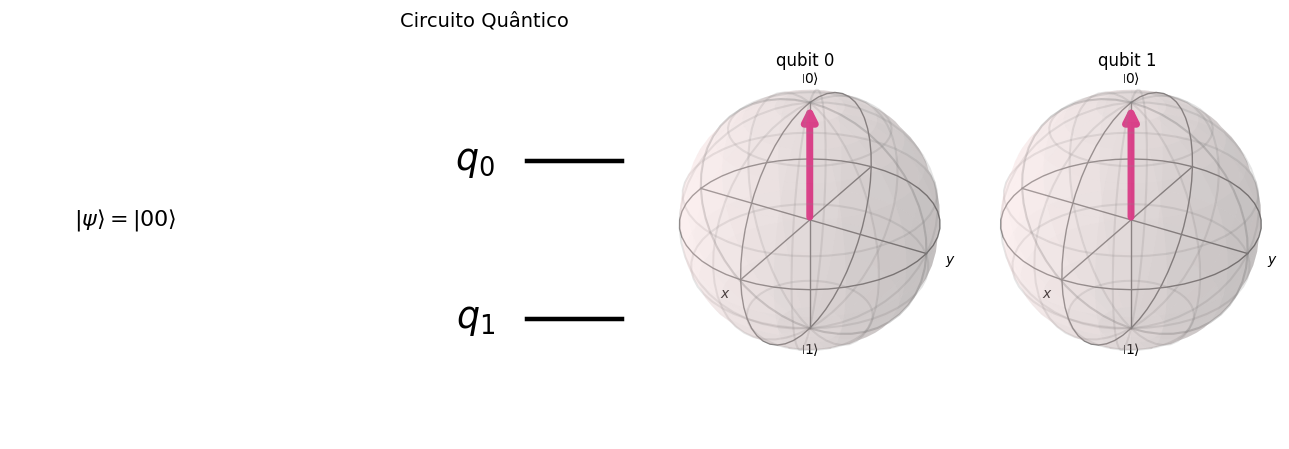

In [ ]:
# Cria circuito quântico com 2 qubits no estado fundamental |00>
# Importante: o Qiskit usa a representação "little endian" e, portanto,
# o bit menos significativo está no início do circuito.
qc = QuantumCircuit(2)
draw_qc_sphere(qc)

### Aplicando a porta Pauli-X sobre o 1$^o$ qubit
$\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}$

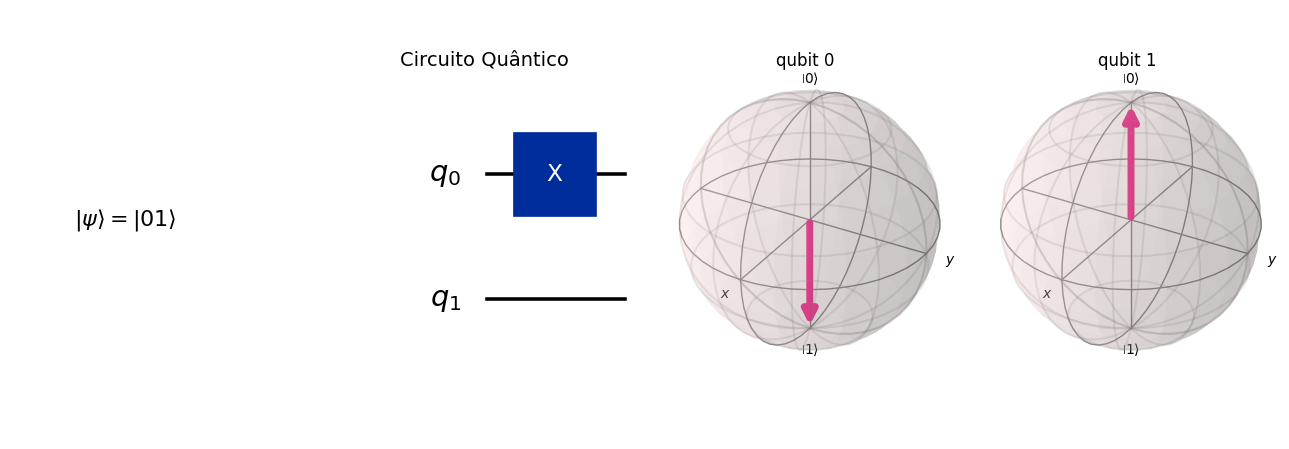

In [ ]:
# Como é um circuito de 2 qubits, no segundo qubit é aplicada a porta Identidade.
# Utiliza-se o operador de kronecker entre X e I em função da dimensão do estado dos 2 qubits
# ou seja, um vetor coluna com 4 linhas será o resultado após aplicação
qc.x(0)
draw_qc_sphere(qc)

### Aplicando a porta Hadamard (H) sobre o 1$^o$ qubit
$\frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}$

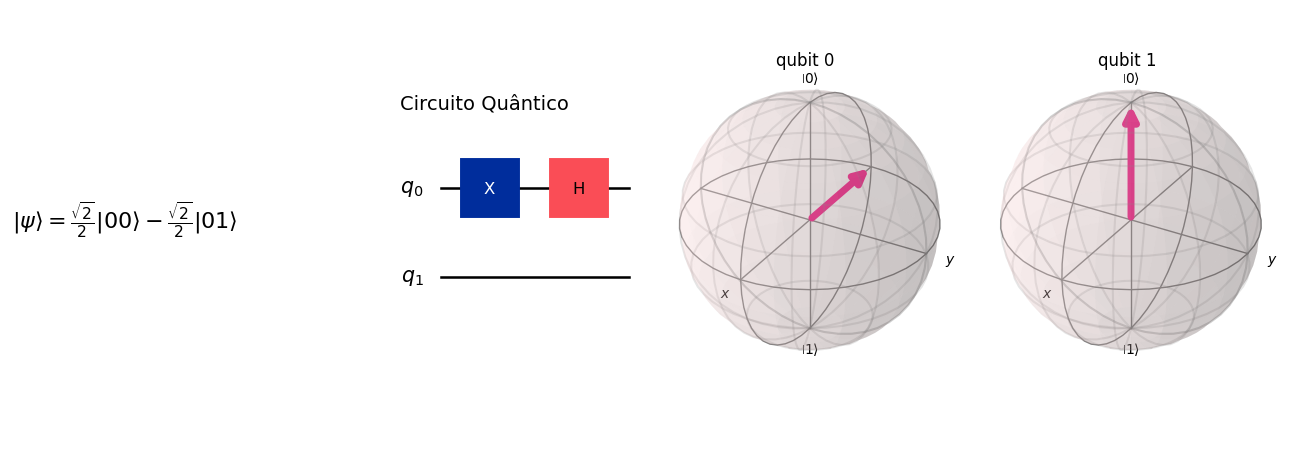

In [ ]:
# Como é um circuito de 2 qubits, no segundo qubit é aplicada a porta Identidade
# O primeiro qubit agora está em superposição em função da aplicação da porta hadamard
# Porta quântica de mudança de base
qc.h(0)
draw_qc_sphere(qc)

### Aplicando a porta CNOT
$\begin{pmatrix}
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
0 & 0 & 1 & 0
\end{pmatrix}$

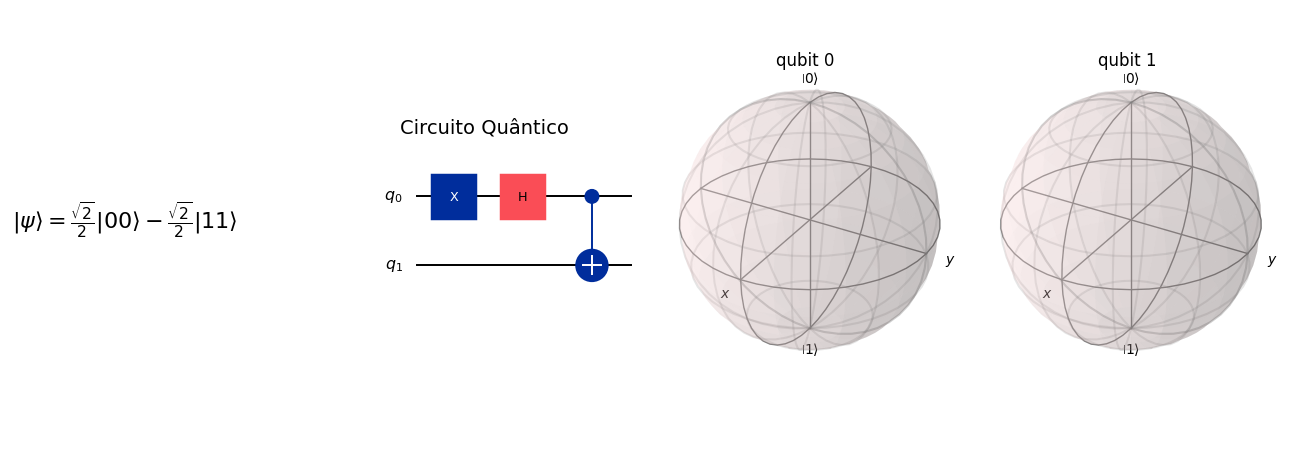

In [ ]:
# A porta CNOT é uma porta específica para 2 qubits. Além disso, ela tem um qubit
# de controle e um qubit de alvo. Quando o qubit de controle é |1>, no qubit
# alvo é aplicado a Pauli-X, ou seja, ocorre uma operação de bit-flip no qubit alvo.
# No estado atual do circuito, tem-se 1/sqrt(2)|00> e -1/sqrt(2)|10>. Portanto,
# o qubit controle do estado |10> está em 1 e, portanto, fará a inversão do segundo qubit,
# resultando em |11>. Ao final, mantém-se a amplitude de probabilidade com fase negativa.
# IMPORTANTE: após aplicação da CNOT o sistema está emaranhado e, portanto, não podemos ver o estado
# do qubit individualmente (ver esfera de Bloch abaixo).
# IMPORTANTE: O estado após aplicação da CNOT é conhecido como um dos 4 estados de Bell. Isso é importante,
# pois são estados conhecidos por serem maximamente emaranhados.
# Como não há informação individual do qubit em função de estarem emaranhados, a esfera de bloch
# não terá representação (o ponto não está na mais na superfície)
qc.cx(0, 1)
draw_qc_sphere(qc)

### Aplicando a porta Hadamard (H) e a porta de rotação $R_y(\pi)$
$H=\frac{1}{\sqrt{2}} \begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}$

$R_y(\theta)=\begin{pmatrix}
cos\frac{\theta}{2} & -sin\frac{\theta}{2} \\
sin\frac{\theta}{2} & cos\frac{\theta}{2}
\end{pmatrix}$

$R_y(\pi)=\begin{pmatrix}
cos \frac{\pi}{2} & -sin\frac{\pi}{2} \\
sin\frac{\pi}{2} & cos\frac{\pi}{2}
\end{pmatrix}$ = $\begin{pmatrix}
0 & -1 \\
1 & 0
\end{pmatrix}$

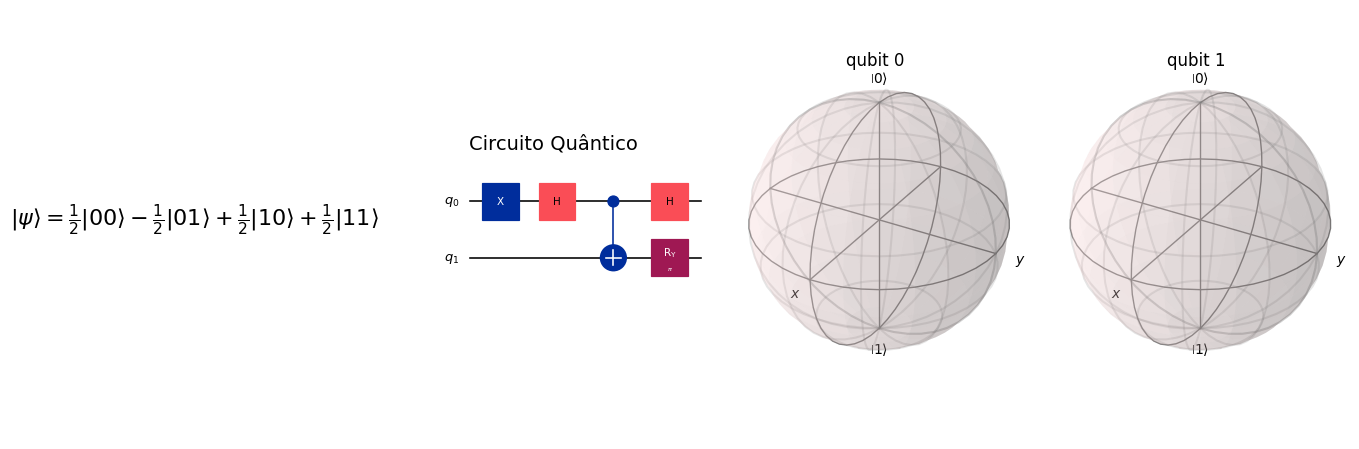

In [ ]:
# Observa-se que o estado está permanece emaranhado após aplicação das duas portas, ou seja, não é um estado separável.
# Também constate-se que não é nenhum dos estados conhecidos da base de Bell, apenas um estado emaranhado (não separável).
# Outra observação é que não podemos representar o sistema individualmente pelos qubits usando a esfera de Bloch.
# Ao final, no circuito quântico, temos o estado |psi> em uma superposição uniforme com amplitude de probabilidade 1/2 e
# o estado |10> com a fase negativa.
# É importante compreender que a porta Ry de pi é o equivalente a uma porta X, porém com inversão de fase
qc.h(0)
qc.ry(np.pi, 1)
draw_qc_sphere(qc)